# 🔍 Busca Semântica da Pokédex com Embeddings e FAISS

> **Notebook completo para Google Colab**
> Permite pesquisar Pokémon usando linguagem natural com busca semântica inteligente.

**Pipeline:**
1. Coleta de dados via PokeAPI (todas as gerações)
2. Construção de documentos textuais ricos
3. Geração de embeddings com `sentence-transformers`
4. Indexação vetorial com FAISS
5. Busca semântica por similaridade de cosseno

**Exemplos de busca:**
- "pokemon inspirados em samurai"
- "pokemon tristes"
- "pokemon parecidos com dragões"
- "pokemon relacionados a espaço"
- "pokemon que parecem deuses"


## 1. Instalação de Dependências

In [ ]:
# Instalar bibliotecas necessárias
!pip install -q sentence-transformers faiss-cpu requests tqdm matplotlib scikit-learn pandas numpy umap-learn rank-bm25

print("✅ Todas as dependências instaladas com sucesso!")
print("   - sentence-transformers (embeddings + cross-encoder)")
print("   - faiss-cpu (busca densa)")
print("   - rank-bm25 (busca lexical/esparsa)")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 37.9 MB/s eta 0:00:00
✅ Todas as dependências instaladas com sucesso!


## 2. Imports e Configuração

In [ ]:
import requests
import json
import time
import pickle
import re
import warnings
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.notebook import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed
from sentence_transformers import SentenceTransformer, CrossEncoder
from rank_bm25 import BM25Okapi
import faiss
from sklearn.manifold import TSNE
from sklearn.preprocessing import normalize
import umap

warnings.filterwarnings('ignore')

# Configuração
POKEAPI_BASE = "https://pokeapi.co/api/v2"
TOTAL_POKEMON = 1025  # Gen 1-9
CACHE_DIR = Path("pokedex_cache")
CACHE_DIR.mkdir(exist_ok=True)

# Idiomas para flavor texts (multi-idioma melhora MUITO a cobertura semântica)
FLAVOR_LANGS = ["en", "es", "pt", "it"]

print(f"📋 Configuração:")
print(f"   Base URL: {POKEAPI_BASE}")
print(f"   Total Pokémon: {TOTAL_POKEMON}")
print(f"   Cache: {CACHE_DIR}")
print(f"   Idiomas dos flavor texts: {FLAVOR_LANGS}")


📋 Configuração:
   Base URL: https://pokeapi.co/api/v2
   Total Pokémon: 1025
   Cache: pokedex_cache


## 3. Coleta de Dados via PokeAPI

Vamos coletar dados detalhados de cada Pokémon:
- **`/pokemon/{id}`**: tipos, abilities, stats base
- **`/pokemon-species/{id}`**: flavor texts, habitat, egg groups, genera

> ⚠️ São ~2050 requests. Usamos cache local + ThreadPoolExecutor para eficiência.

In [4]:
def fetch_with_cache(url, cache_key):
    """Faz request com cache local em disco."""
    cache_file = CACHE_DIR / f"{cache_key}.json"
    if cache_file.exists():
        with open(cache_file, 'r', encoding='utf-8') as f:
            return json.load(f)
    try:
        resp = requests.get(url, timeout=30)
        resp.raise_for_status()
        data = resp.json()
        with open(cache_file, 'w', encoding='utf-8') as f:
            json.dump(data, f)
        return data
    except Exception as e:
        return None

def fetch_pokemon_data(pokemon_id):
    """Coleta dados completos de um Pokémon (pokemon + species)."""
    pokemon = fetch_with_cache(
        f"{POKEAPI_BASE}/pokemon/{pokemon_id}",
        f"pokemon_{pokemon_id}"
    )
    species = fetch_with_cache(
        f"{POKEAPI_BASE}/pokemon-species/{pokemon_id}",
        f"species_{pokemon_id}"
    )
    if not pokemon or not species:
        return None
    return {"pokemon": pokemon, "species": species, "id": pokemon_id}

# Coleta paralela com progress bar
print("🔄 Coletando dados de todos os Pokémon...")
all_pokemon_data = []
failed = []

with ThreadPoolExecutor(max_workers=10) as executor:
    futures = {executor.submit(fetch_pokemon_data, i): i for i in range(1, TOTAL_POKEMON + 1)}
    for future in tqdm(as_completed(futures), total=TOTAL_POKEMON, desc="Pokémon"):
        pid = futures[future]
        try:
            result = future.result()
            if result:
                all_pokemon_data.append(result)
            else:
                failed.append(pid)
        except Exception:
            failed.append(pid)

all_pokemon_data.sort(key=lambda x: x["id"])
print(f"\n✅ Coletados: {len(all_pokemon_data)} Pokémon")
if failed:
    print(f"⚠️ Falhas: {len(failed)} IDs: {failed[:20]}...")

🔄 Coletando dados de todos os Pokémon...


Pokémon:   0%|          | 0/1025 [00:00<?, ?it/s]


✅ Coletados: 1025 Pokémon


## 4. Coleta de Descrições de Abilities

In [5]:
# Coletar descrições únicas de abilities
print("🔄 Coletando descrições de abilities...")
unique_abilities = set()
for pdata in all_pokemon_data:
    for ab in pdata["pokemon"].get("abilities", []):
        ability_name = ab["ability"]["name"]
        unique_abilities.add(ability_name)

ability_descriptions = {}
def fetch_ability(name):
    data = fetch_with_cache(f"{POKEAPI_BASE}/ability/{name}", f"ability_{name}")
    if data:
        entries = [e["effect"] for e in data.get("effect_entries", []) if e["language"]["name"] == "en"]
        short = [e["short_effect"] for e in data.get("effect_entries", []) if e["language"]["name"] == "en"]
        desc = entries[0] if entries else (short[0] if short else "")
        return name, desc
    return name, ""

with ThreadPoolExecutor(max_workers=10) as executor:
    futures = [executor.submit(fetch_ability, name) for name in unique_abilities]
    for future in tqdm(as_completed(futures), total=len(unique_abilities), desc="Abilities"):
        name, desc = future.result()
        ability_descriptions[name] = desc

print(f"✅ {len(ability_descriptions)} abilities coletadas")

🔄 Coletando descrições de abilities...


Abilities:   0%|          | 0/284 [00:00<?, ?it/s]

✅ 284 abilities coletadas


## 5. Construção do Dataset Textual Enriquecido (Prosa Multi-idioma + Interpretação Semântica)

Para cada Pokémon construímos um **documento em prosa natural** (sem keyword stuffing). A receita:

1. 🥇 **Flavor texts oficiais em EN + ES + FR + IT** (PokeAPI tem cada Pokédex entry traduzida)
2. 🥈 **Interpretação semântica curada** — convertemos atributos estruturais em frases descritivas que conectam ao **significado humano** (lendário → "divindade criadora", color+shape → aparência, stats → comportamento em batalha)
3. 🥉 **Lore + categoria + habitat + abilities** em frases completas
4. **NÃO usamos** listas separadas por vírgula nem "palavras-chave" — embeddings degradam com bag-of-words

> Isso permite que "pokemon deuses" encontre Arceus mesmo sem o texto dizer "deus", e que "fofo" encontre Jigglypuff via inferência semântica.

In [ ]:
# =============================================================================
# CONSTRUÇÃO DE DOCUMENTOS — PROSA NATURAL + INTERPRETAÇÃO SEMÂNTICA
# =============================================================================
# Princípio: embeddings funcionam com PROSA, não com listas de keywords.
# Cada atributo vira uma frase descritiva em linguagem natural.
# Adicionamos "ground truth" semântico que a PokeAPI não dá (ex: lendários
# são divindades, certos formatos são fofos, etc.)
# =============================================================================

# ── Interpretação narrativa de TIPOS (não keywords) ──
TIPO_NARRATIVA = {
    "fire": "Como Pokémon do tipo fogo, domina chamas, calor intenso e brasas ardentes.",
    "water": "Como Pokémon do tipo água, vive em ambientes aquáticos como oceanos, rios e mares, controlando correntes e chuva.",
    "grass": "Como Pokémon do tipo planta, possui afinidade com florestas, folhagens e natureza viva.",
    "electric": "Como Pokémon do tipo elétrico, gera eletricidade, raios e descargas de alta voltagem.",
    "psychic": "Como Pokémon do tipo psíquico, usa poderes mentais, telepatia e telecinese.",
    "dark": "Como Pokémon do tipo sombrio, é noturno, sinistro e usa táticas traiçoeiras.",
    "fairy": "Como Pokémon do tipo fada, é mágico, encantado e tem uma aura adorável e mística.",
    "dragon": "Como Pokémon do tipo dragão, é uma criatura imponente, antiga e poderosa, frequentemente reverenciada como lendária.",
    "ghost": "Como Pokémon do tipo fantasma, é uma criatura espectral, assombrosa, ligada à morte e ao sobrenatural, capaz de provocar medo e terror.",
    "steel": "Como Pokémon do tipo aço, possui corpo metálico, blindado, com partes mecânicas resistentes.",
    "fighting": "Como Pokémon do tipo lutador, é um guerreiro marcial treinado em combate corpo a corpo.",
    "poison": "Como Pokémon do tipo veneno, exala toxinas perigosas e ataques venenosos.",
    "ground": "Como Pokémon do tipo terra, vive em solo, areia ou cavernas subterrâneas.",
    "rock": "Como Pokémon do tipo pedra, tem corpo rochoso e mineral, muitas vezes ligado a fósseis antigos.",
    "ice": "Como Pokémon do tipo gelo, habita ambientes congelados, neve e geleiras.",
    "flying": "Como Pokémon do tipo voador, plana pelos céus com asas, dominando o ar e as alturas.",
    "bug": "Como Pokémon do tipo inseto, lembra besouros, borboletas, aranhas ou outros artrópodes.",
    "normal": "Como Pokémon do tipo normal, é uma criatura comum, frequentemente baseada em animais reais.",
}

# Tipos que evocam um "feel" específico (combos)
COMBO_HINTS = {
    frozenset(["fire", "flying"]): "Voa pelos céus cuspindo fogo e chamas, lembrando dragões alados clássicos da mitologia.",
    frozenset(["dragon", "flying"]): "Um verdadeiro dragão voador, majestoso e temível.",
    frozenset(["water", "flying"]): "Plana sobre oceanos e rios, como uma ave marinha ou criatura aquática alada.",
    frozenset(["ghost", "fire"]): "Uma alma flamejante e assombrosa, espírito ardente do submundo.",
    frozenset(["psychic", "fairy"]): "Uma criatura mágica e mental, etérea e encantadora.",
    frozenset(["dark", "ghost"]): "Um ser sinistro e assombroso, ligado a pesadelos e horrores.",
    frozenset(["ice", "dragon"]): "Um dragão glacial das terras congeladas.",
    frozenset(["steel", "psychic"]): "Uma máquina ou ser robótico de inteligência sobrenatural.",
}

HABITAT_NARRATIVA = {
    "cave": "Vive escondido em cavernas escuras e profundezas subterrâneas.",
    "forest": "Habita densas florestas e bosques cobertos de árvores.",
    "grassland": "Vive em campos abertos, planícies e pradarias.",
    "mountain": "Habita montanhas escarpadas e picos rochosos.",
    "rare": "É extremamente raro, dificilmente avistado, quase mítico em sua presença.",
    "rough-terrain": "Vive em terrenos hostis como desertos e pântanos.",
    "sea": "Vive nas profundezas do oceano, no mar abissal e em águas marinhas.",
    "urban": "Adaptou-se à vida em cidades e ambientes humanos.",
    "waters-edge": "Vive próximo a rios, lagos e linhas costeiras.",
}

SHAPE_NARRATIVA = {
    "ball": "Tem corpo redondo, arredondado, com formato de bola ou esfera fofa.",
    "squiggle": "Tem corpo alongado, serpentino, sinuoso como uma cobra.",
    "fish": "Tem formato de peixe, com nadadeiras e corpo aquático.",
    "arms": "Possui braços proeminentes como característica marcante.",
    "blob": "Tem corpo amorfo, gelatinoso, sem forma definida, como uma gosma.",
    "upright": "Anda ereto sobre duas pernas, com postura bípede semelhante a humanos.",
    "legs": "Possui pernas destacadas como característica principal.",
    "quadruped": "Anda em quatro patas, com corpo de quadrúpede como cães, gatos ou cavalos.",
    "wings": "Possui asas grandes e voa, lembrando aves ou dragões alados.",
    "tentacles": "Tem tentáculos e membros flexíveis, lembrando polvos ou medusas.",
    "heads": "Possui múltiplas cabeças, criatura de aparência fantástica e mitológica.",
    "humanoid": "Tem aparência humanoide, antropomórfica, similar a uma pessoa.",
    "bug-wings": "Possui asas de inseto e corpo de artrópode alado, como borboletas ou besouros voadores.",
    "armor": "Tem corpo coberto por armadura ou couraça blindada, lembrando guerreiros ou cavaleiros.",
}

COLOR_NARRATIVA = {
    "black": "Sua coloração é preta e sombria.",
    "blue": "Possui coloração azul, lembrando o céu, água ou gelo.",
    "brown": "Tem coloração marrom e terrosa.",
    "gray": "É de cor cinza, frequentemente metálico ou rochoso.",
    "green": "Possui coloração verde, evocando plantas e natureza.",
    "pink": "É rosa, geralmente com aparência fofa e adorável.",
    "purple": "Tem coloração roxa, frequentemente associada a magia, veneno ou mistério.",
    "red": "É vermelho, cor de fogo, sangue ou paixão.",
    "white": "Tem coloração branca, pura, angelical ou nevada.",
    "yellow": "É amarelo, frequentemente brilhante como sol ou eletricidade.",
}

# Egg groups que dão dicas semânticas fortes
EGG_GROUP_NARRATIVA = {
    "monster": "Pertence ao grupo de monstros reptilianos pré-históricos.",
    "human-like": "É uma criatura humanoide inteligente e antropomórfica.",
    "fairy": "Pertence ao grupo das fadas: pequeno, fofo, adorável e encantador.",
    "dragon": "Pertence à linhagem dos dragões antigos.",
    "mineral": "É um ser mineral, cristalino, feito de rocha ou metal.",
    "amorphous": "É uma criatura amorfa, sem forma fixa, gasosa ou fantasmagórica.",
    "undiscovered": "Pertence ao grupo dos Pokémon misteriosos de origem desconhecida, frequentemente lendários ou míticos.",
    "water1": "É uma criatura aquática, nadadora.",
    "water2": "É um peixe ou criatura marinha.",
    "water3": "É um crustáceo ou invertebrado marinho.",
    "bug": "É um inseto ou artrópode.",
    "flying": "É uma criatura alada, ave ou similar.",
    "field": "É um mamífero ou animal terrestre comum.",
    "grass": "É uma criatura vegetal ou botânica.",
    "ditto": "É um metamorfo capaz de se transformar.",
}

# ── Lista CURADA de Pokémon "ícones culturais" — injeta conceitos que a API não dá ──
# Esta é a parte mais importante: damos ao modelo o conhecimento humano que falta.
LORE_INTERPRETATIVO = {
    # Divindades / criadores
    "arceus": "Arceus é venerado como o Pokémon Original, o deus criador de todo o universo Pokémon. É a divindade suprema, considerada o criador de tudo, equivalente a um Deus na mitologia Pokémon.",
    "dialga": "Dialga é um deus do tempo, divindade que controla o fluxo temporal do universo, parte da trindade criadora.",
    "palkia": "Palkia é um deus do espaço, divindade que controla as dimensões espaciais do universo, parte da trindade criadora.",
    "giratina": "Giratina é o deus do mundo distorcido, divindade caída banida para uma dimensão paralela, parte da trindade criadora.",
    "ho-oh": "Ho-Oh é uma divindade lendária, fênix sagrada do arco-íris, considerada um deus protetor.",
    "lugia": "Lugia é uma divindade lendária dos mares, guardiã dos oceanos, considerada um deus dos mares profundos.",
    "rayquaza": "Rayquaza é um deus dragão dos céus, divindade serpentina que vive na ozonosfera, protetor do mundo.",
    "kyogre": "Kyogre é um deus dos oceanos, criador dos mares, divindade primordial da água.",
    "groudon": "Groudon é um deus dos continentes, criador da terra, divindade primordial dos solos.",
    "mewtwo": "Mewtwo é uma criatura geneticamente modificada de poder divino, considerado um deus psíquico criado pelo homem.",
    "mew": "Mew é o ancestral místico de todos os Pokémon, criatura primordial com aparência fofa e adorável.",
    "calyrex": "Calyrex é o Rei Divino, monarca lendário considerado um deus benevolente que governa com sabedoria.",
    "eternatus": "Eternatus é uma divindade cósmica destrutiva vinda do espaço sideral, criatura alienígena dos confins do universo.",
    "necrozma": "Necrozma é uma entidade cósmica que devora luz, ser ultradimensional vindo de outro universo.",

    # Espaço / cosmos
    "deoxys": "Deoxys é um Pokémon alienígena vindo do espaço sideral, mutação de DNA cósmico de um meteoro do universo.",
    "jirachi": "Jirachi é um Pokémon mítico das estrelas que concede desejos, vindo de um cometa celeste do cosmos.",
    "solrock": "Solrock é uma criatura solar, baseado no sol, vindo do espaço sideral com forma de astro estelar.",
    "lunatone": "Lunatone é uma criatura lunar, baseado na lua, vindo do espaço sideral com forma de astro celeste.",
    "cosmog": "Cosmog é uma nebulosa viva, criatura cósmica feita de gás estelar do espaço sideral.",
    "cosmoem": "Cosmoem é a forma embrionária cósmica, casulo estelar do espaço sideral.",
    "solgaleo": "Solgaleo é a fera solar, criatura cósmica que devora a luz do sol no universo.",
    "lunala": "Lunala é a fera lunar, criatura cósmica que invoca a lua e a noite estrelada do cosmos.",
    "minior": "Minior é um meteorito vivo, criatura espacial caída do cinturão estelar cósmico.",
    "clefairy": "Clefairy é uma fada fofa vinda do espaço sideral, criatura adorável associada à lua e estrelas.",

    # Fofos / adoráveis (importante: PokeAPI não diz "fofo" em lugar nenhum!)
    "pikachu": "Pikachu é mundialmente conhecido por sua aparência fofa, adorável e cativante, mascote dos Pokémon.",
    "jigglypuff": "Jigglypuff é extremamente fofo, redondo, rosa e adorável, com aparência de bolinha encantadora.",
    "togepi": "Togepi é um bebê Pokémon fofo e adorável, pequenino e cativante.",
    "eevee": "Eevee é um Pokémon fofo, adorável, de pelagem macia, parecido com uma raposinha encantadora.",
    "sylveon": "Sylveon é uma fada fofa e elegante, com fitas e aparência encantadora e adorável.",
    "mimikyu": "Mimikyu se disfarça com um pano fofo imitando Pikachu para ser amado, mas por dentro é um fantasma triste e solitário.",
    "dedenne": "Dedenne é um ratinho fofo e adorável, pequeno e encantador.",
    "comfey": "Comfey é uma fada fofa em forma de colar de flores, delicada e encantadora.",
    "alcremie": "Alcremie é uma fada fofa feita de creme e doces, adorável como uma sobremesa.",
    "skitty": "Skitty é um gatinho fofo e brincalhão, extremamente adorável.",
    "azurill": "Azurill é um bebê Pokémon fofo, pequeno e azulado, adorável.",

    # Tristes / sozinhos / abandonados
    "cubone": "Cubone é o Pokémon Solitário, triste, melancólico, que chora pela mãe morta e usa o crânio dela como máscara.",
    "absol": "Absol é uma criatura solitária e melancólica, evitada por ser confundida com presságio de desastres, vivendo isolada nas montanhas.",
    "banette": "Banette é um boneco de pelúcia abandonado que ganhou vida por rancor e tristeza, buscando vingança contra quem o jogou fora.",
    "phantump": "Phantump é o espírito triste de uma criança que se perdeu na floresta e morreu sozinha, alma melancólica presa em um toco.",
    "drifloon": "Drifloon é um balão fantasma melancólico, espírito de almas perdidas, triste e solitário.",
    "mimikyu_sad": "Mimikyu vive sozinho e triste, fantasma melancólico que se esconde sob um pano por solidão e medo de rejeição.",
    "spiritomb": "Spiritomb é a alma punida de 108 espíritos amaldiçoados, presa em uma rocha por seus pecados.",
    "yamask": "Yamask é o espírito triste de um humano morto que carrega sua antiga máscara mortuária chorando pela vida perdida.",
    "litwick": "Litwick é uma vela viva que drena a vida de seres tristes, espectro melancólico que ronda os moribundos.",

    # Pesadelos / horror / medo
    "darkrai": "Darkrai é o Pokémon dos pesadelos, uma criatura sombria que invoca terror, medo e visões assombrosas durante o sono.",
    "gengar": "Gengar é um fantasma assombroso e sorridente, espírito malicioso que assusta humanos nas sombras, criatura de pesadelo.",
    "haunter": "Haunter é um fantasma assombroso que aterroriza humanos com sua língua flutuante, espectro de pesadelo.",
    "duskull": "Duskull é um fantasma da morte, ceifador infantil com aparência aterrorizante, espírito do medo.",
    "chandelure": "Chandelure é um candelabro fantasmagórico que queima almas humanas com suas chamas espectrais, criatura de horror.",
    "gourgeist": "Gourgeist é uma abóbora fantasma assombrosa de Halloween, espírito sinistro do dia das bruxas.",
    "trevenant": "Trevenant é uma árvore fantasma assombrosa que captura e devora pessoas perdidas na floresta.",
    "shedinja": "Shedinja é uma carcaça oca fantasmagórica, casca vazia assombrosa que rouba almas pelo buraco nas costas.",
    "dusknoir": "Dusknoir é o ceifador da morte que leva almas ao outro mundo, espectro aterrorizante.",

    # Robóticos / mecânicos
    "magnemite": "Magnemite é um robô magnético artificial feito de aço, máquina elétrica de aparência tecnológica.",
    "magneton": "Magneton é uma combinação de robôs magnéticos, máquina elétrica artificial.",
    "porygon": "Porygon é um Pokémon de dados, criatura virtual artificial criada por programação, ser robótico digital.",
    "genesect": "Genesect é um inseto ciborgue antigo modificado com tecnologia, máquina biológica armada com canhão.",
    "magearna": "Magearna é uma boneca robótica artificial criada por engenharia humana, autômato mecânico antigo.",
    "metagross": "Metagross é um supercomputador robótico vivo, máquina de aço com quatro cérebros conectados.",
    "registeel": "Registeel é uma criatura artificial de aço puro, autômato metálico ancestral.",
    "golurk": "Golurk é um golem gigante mecânico de barro selado, máquina ancestral robótica de origem misteriosa.",
    "type-null": "Type: Null é uma criatura artificial criada em laboratório, quimera sintética robótica de bioengenharia.",
    "klinklang": "Klinklang é uma engrenagem mecânica viva, máquina industrial de aço com partes rotativas.",
    "rotom": "Rotom é um espírito elétrico que possui aparelhos eletrônicos, fantasma robótico tecnológico.",
    "beldum": "Beldum é uma forma robótica metálica simples, máquina de aço elementar.",

    # Mitologia japonesa / oriental
    "ninetales": "Ninetales é baseado no Kitsune da mitologia japonesa, raposa mística de nove caudas com poderes sobrenaturais lendários.",
    "vulpix": "Vulpix é uma raposa de fogo baseada no Kitsune japonês, criatura mística do folclore oriental.",
    "arcanine": "Arcanine é baseado no cão Komainu e nos shisa, guardião lendário do folclore japonês oriental.",
    "absol_myth": "Absol é baseado nos presságios da mitologia japonesa, criatura mística que avisa de desastres.",
    "lucario": "Lucario domina o aura, baseado nas artes marciais orientais e em criaturas da mitologia chinesa e japonesa, lembrando um guerreiro Aura.",
    "zoroark": "Zoroark é baseado no Kitsune trapaceiro do folclore japonês, raposa mística mestre da ilusão e mentira.",
    "greninja": "Greninja é um ninja sapo inspirado nos shinobi do Japão feudal, mestre das sombras e armas de água.",
    "suicune": "Suicune é uma fera lendária inspirada nos animais sagrados orientais, criatura mística da mitologia japonesa.",
    "raikou": "Raikou é uma fera lendária inspirada em criaturas elétricas da mitologia oriental japonesa.",
    "entei": "Entei é uma fera lendária inspirada em cães de fogo da mitologia oriental japonesa.",
    "kommo-o": "Kommo-o é um guerreiro dragão inspirado em samurais japoneses, lutador escamado oriental.",
    "honedge": "Honedge é uma espada katana possuída por espíritos, arma samurai amaldiçoada do folclore japonês.",
    "aegislash": "Aegislash é o espírito de um espada real, baseado em katanas samurais reais do Japão antigo.",
    "bisharp": "Bisharp é um guerreiro samurai de aço com lâminas, lutador oriental armado.",
    "samurott": "Samurott é um samurai aquático com espadas, guerreiro oriental do mar.",
    "scrafty": "Scrafty é baseado em delinquentes mas com elementos de répteis lutadores orientais.",

    # Predadores perigosos / monstros agressivos
    "gyarados": "Gyarados é um monstro marinho aterrorizante, predador devastador que destrói cidades em fúria, criatura monstruosa do oceano.",
    "tyranitar": "Tyranitar é um monstro destrutivo agressivo, predador devastador que causa terremotos com sua fúria.",
    "salamence": "Salamence é um dragão predador agressivo voador, monstro alado destrutivo que ataca tudo em seu caminho.",
    "garchomp": "Garchomp é um predador agressivo de areia, dragão terrestre veloz e mortal, caçador implacável.",
    "haxorus": "Haxorus é um dragão predador agressivo com presas de aço, criatura monstruosa destrutiva.",
    "drapion": "Drapion é um escorpião gigante predador agressivo e venenoso, criatura monstruosa do deserto.",
    "hydreigon": "Hydreigon é uma hidra dragão de três cabeças, monstro brutal e destrutivo agressivo.",
    "sharpedo": "Sharpedo é um tubarão predador agressivo do oceano, caçador feroz devastador.",
    "feraligatr": "Feraligatr é um crocodilo monstruoso predador agressivo de presas afiadas.",
    "krookodile": "Krookodile é um crocodilo predador agressivo do deserto, caçador implacável e destrutivo.",

    # Fósseis pré-históricos
    "archen": "Archen é um Pokémon fóssil pré-histórico extinto, ave ancestral antiga revivida de pedras antigas.",
    "arctovish": "Arctovish é um Pokémon fóssil pré-histórico extinto, peixe ancestral congelado antigo revivido.",
    "dracozolt": "Dracozolt é um Pokémon fóssil pré-histórico extinto, dinossauro elétrico antigo revivido de eras passadas.",
    "dracovish": "Dracovish é um Pokémon fóssil pré-histórico extinto, peixe-dragão ancestral antigo revivido.",
    "arctozolt": "Arctozolt é um Pokémon fóssil pré-histórico extinto, criatura congelada antiga revivida.",
}


def clean_text(text):
    """Remove caracteres especiais e normaliza espaços."""
    text = re.sub(r'[\x0c\n\r\t]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()


def get_flavor_texts(species, lang, max_unique=8):
    """Retorna até N flavor texts únicos de um idioma, em ordem de jogo."""
    seen = set()
    texts = []
    for entry in species.get("flavor_text_entries", []):
        if entry["language"]["name"] != lang:
            continue
        text = clean_text(entry["flavor_text"])
        norm = re.sub(r'[^\w\s]', '', text.lower()).strip()
        if norm and norm not in seen:
            seen.add(norm)
            texts.append(text)
            if len(texts) >= max_unique:
                break
    return texts


def build_pokemon_document(pdata):
    """
    Constrói documento em PROSA NATURAL (sem keyword stuffing).
    Combina: nome, categoria, lore multilíngue, interpretação semântica curada,
    descrição narrativa de tipos/habitat/aparência/stats em frases completas.
    """
    pokemon = pdata["pokemon"]
    species = pdata["species"]
    name_slug = pokemon["name"]
    name = name_slug.replace("-", " ").title()
    parts = []

    # ── 1. IDENTIDADE ──
    genus_en = next((g["genus"] for g in species.get("genera", []) if g["language"]["name"] == "en"), None)
    genus_pt = next((g["genus"] for g in species.get("genera", []) if g["language"]["name"] in ("es", "fr", "it")), None)
    if genus_en:
        parts.append(f"{name} is the {genus_en}.")
    if genus_pt:
        parts.append(f"{name} é {genus_pt}.")

    # ── 2. STATUS LENDÁRIO/MÍTICO (prosa rica) ──
    if species.get("is_legendary"):
        parts.append(
            f"{name} é um Pokémon Lendário, criatura suprema e rara reverenciada em mitos antigos como uma divindade poderosa."
        )
        parts.append(
            f"{name} is a Legendary Pokémon, a supreme rare creature revered in ancient myths as a powerful divine being."
        )
    if species.get("is_mythical"):
        parts.append(
            f"{name} é um Pokémon Mítico, criatura sagrada envolta em mistério, raríssima e quase divina em sua presença."
        )
        parts.append(
            f"{name} is a Mythical Pokémon, a sacred and almost divine creature shrouded in mystery."
        )

    # ── 3. LORE INTERPRETATIVO CURADO (a chave!) ──
    if name_slug in LORE_INTERPRETATIVO:
        parts.append(LORE_INTERPRETATIVO[name_slug])
    # Algumas chaves "duplas" para conceitos sobrepostos
    for extra_key in [f"{name_slug}_sad", f"{name_slug}_myth"]:
        if extra_key in LORE_INTERPRETATIVO:
            parts.append(LORE_INTERPRETATIVO[extra_key])

    # ── 4. FLAVOR TEXTS MULTI-IDIOMA (lore oficial) ──
    for lang in FLAVOR_LANGS:
        texts = get_flavor_texts(species, lang, max_unique=6)
        parts.extend(texts)

    # ── 5. TIPOS em PROSA (sem listas de keywords) ──
    types = [t["type"]["name"] for t in pokemon["types"]]
    for t in types:
        if t in TIPO_NARRATIVA:
            parts.append(TIPO_NARRATIVA[t])
    # Combos especiais
    combo_key = frozenset(types)
    if combo_key in COMBO_HINTS:
        parts.append(COMBO_HINTS[combo_key])

    # ── 6. HABITAT em prosa ──
    habitat = species.get("habitat")
    if habitat and habitat["name"] in HABITAT_NARRATIVA:
        parts.append(HABITAT_NARRATIVA[habitat["name"]])

    # ── 7. EGG GROUPS em prosa ──
    for eg in species.get("egg_groups", []):
        if eg["name"] in EGG_GROUP_NARRATIVA:
            parts.append(EGG_GROUP_NARRATIVA[eg["name"]])

    # ── 8. ABILITIES (já vêm em prosa do PokeAPI) ──
    for ab in pokemon.get("abilities", []):
        ab_name = ab["ability"]["name"].replace("-", " ").title()
        ab_desc = ability_descriptions.get(ab["ability"]["name"], "")
        if ab_desc:
            parts.append(f"Its ability {ab_name}: {clean_text(ab_desc)}")

    # ── 9. STATS como narrativa rica em PROSA ──
    stats = {s["stat"]["name"]: s["base_stat"] for s in pokemon["stats"]}
    hp = stats.get("hp", 0); atk = stats.get("attack", 0); dfn = stats.get("defense", 0)
    spa = stats.get("special-attack", 0); spd = stats.get("special-defense", 0); spe = stats.get("speed", 0)
    bst = sum(stats.values())

    if atk >= 120 or spa >= 120:
        parts.append(f"{name} é extremamente poderoso ofensivamente, um atacante devastador e destrutivo em batalha.")
    elif atk >= 100 or spa >= 100:
        parts.append(f"{name} é um atacante forte e agressivo em batalha.")
    if dfn >= 120 or spd >= 120:
        parts.append(f"{name} é incrivelmente resistente, um verdadeiro muro defensivo tanque em batalha.")
    if spe >= 120:
        parts.append(f"{name} é extremamente rápido, veloz e ágil em batalha.")
    elif spe <= 35:
        parts.append(f"{name} é muito lento e pesado, com baixa velocidade.")
    if hp >= 120:
        parts.append(f"{name} tem enorme vitalidade e resistência física.")
    if bst >= 600:
        parts.append(f"{name} possui poder de nível pseudo-lendário ou lendário, força de elite.")

    # ── 10. APARÊNCIA (cor + forma em prosa) ──
    color = species.get("color")
    if color and color["name"] in COLOR_NARRATIVA:
        parts.append(COLOR_NARRATIVA[color["name"]])
    shape = species.get("shape")
    if shape and shape["name"] in SHAPE_NARRATIVA:
        parts.append(SHAPE_NARRATIVA[shape["name"]])

    # Pokémon "baby" sempre são fofos
    if species.get("is_baby"):
        parts.append(f"{name} é um Pokémon bebê, pequeno, fofo e adorável.")

    # ── 11. REGIÃO ──
    gen_url = species.get("generation", {}).get("url", "")
    if gen_url:
        gen_num = gen_url.rstrip("/").split("/")[-1]
        gen_names = {"1": "Kanto", "2": "Johto", "3": "Hoenn", "4": "Sinnoh", "5": "Unova",
                     "6": "Kalos", "7": "Alola", "8": "Galar", "9": "Paldea"}
        region = gen_names.get(gen_num, f"Geração {gen_num}")
        parts.append(f"{name} é originário da região de {region}.")

    return " ".join(parts)


# Construir documentos
print("📝 Construindo documentos em prosa natural multi-idioma...")
documents = []
metadata = []
for pdata in tqdm(all_pokemon_data, desc="Documentos"):
    doc = build_pokemon_document(pdata)
    pokemon = pdata["pokemon"]
    species = pdata["species"]
    gen_url = species.get("generation", {}).get("url", "")
    gen_num = int(gen_url.rstrip("/").split("/")[-1]) if gen_url else 0
    documents.append(doc)
    metadata.append({
        "id": pdata["id"],
        "name": pokemon["name"].replace("-", " ").title(),
        "slug": pokemon["name"],
        "types": [t["type"]["name"] for t in pokemon["types"]],
        "sprite": pokemon["sprites"]["front_default"],
        "is_legendary": species.get("is_legendary", False),
        "is_mythical": species.get("is_mythical", False),
        "habitat": species.get("habitat", {}).get("name", "unknown") if species.get("habitat") else "unknown",
        "generation": gen_num,
        "color": species.get("color", {}).get("name", "unknown") if species.get("color") else "unknown",
    })

df = pd.DataFrame(metadata)
df["document"] = documents
print(f"\n✅ {len(documents)} documentos construídos em prosa natural")
print(f"📊 Tamanho médio: {np.mean([len(d) for d in documents]):.0f} caracteres")
print(f"📊 Tamanho máximo: {max(len(d) for d in documents)} caracteres")
print(f"\n📄 Exemplo (Charizard):")
ci = df[df['name'].str.contains('Charizard', case=False)].index
if len(ci) > 0:
    print(documents[ci[0]][:1200] + "...\n")
print(f"📄 Exemplo (Arceus):")
ai = df[df['name'].str.contains('Arceus', case=False)].index
if len(ai) > 0:
    print(documents[ai[0]][:1200] + "...")


📝 Construindo documentos textuais bilíngues (PT-BR + EN)...


Documentos:   0%|          | 0/1025 [00:00<?, ?it/s]


✅ 1025 documentos bilíngues construídos
📊 Tamanho médio: 1825 caracteres

📄 Exemplo (Charizard):
Charizard, the Flame Pokémon. Spits fire that is hot enough to melt boulders. Known to cause forest fires unintentionally. When expelling a blast of super hot fire, the red flame at the tip of its tail burns more intensely. If CHARIZARD be­ comes furious, the flame at the tip of its tail flares up in a whitish- blue color. Breathing intense, hot flames, it can melt almost any­ thing. Its breath inflicts terrible pain on enemies. It uses its wings to fly high. The temperature of its fire increases as it gains exper­ ience in battle. CHARIZARD flies around the sky in search of powerful opponents. It breathes fire of such great heat that it melts anything. However, it never turns its fiery breath on any opponent weaker than itself. A CHARIZARD flies about in search of strong opponents. It bre...


## 6. Geração dos Embeddings Semânticos (Multilingual E5)

Utilizamos **`intfloat/multilingual-e5-base`**:
- 768 dimensões (vs 384 do MiniLM antigo)
- SOTA em benchmarks multilíngues (PT-BR nativo, top-tier no MTEB)
- Treinado especificamente para retrieval com **prefixos**:
  - `passage: <texto>` para documentos
  - `query: <texto>` para consultas
- ~280MB, ainda roda bem em CPU


In [ ]:
# Carregar modelo MULTILINGUAL E5 (SOTA para retrieval multilíngue)
print("🔄 Carregando modelo intfloat/multilingual-e5-base...")
EMBED_MODEL_NAME = "intfloat/multilingual-e5-base"
model = SentenceTransformer(EMBED_MODEL_NAME)
print(f"✅ Modelo carregado: {EMBED_MODEL_NAME}")
print(f"   Dimensões: {model.get_sentence_embedding_dimension()}")
print(f"   Max seq length: {model.max_seq_length}")

# E5 exige prefixos específicos para passages e queries
def encode_passages(texts, batch_size=32):
    """Encode documentos com prefixo 'passage:' (recomendado pelo E5)."""
    prefixed = [f"passage: {t}" for t in texts]
    return model.encode(
        prefixed,
        show_progress_bar=True,
        batch_size=batch_size,
        normalize_embeddings=True,
        convert_to_numpy=True,
    ).astype('float32')

def encode_queries(texts, batch_size=32):
    """Encode queries com prefixo 'query:' (recomendado pelo E5)."""
    prefixed = [f"query: {t}" for t in texts]
    return model.encode(
        prefixed,
        show_progress_bar=False,
        batch_size=batch_size,
        normalize_embeddings=True,
        convert_to_numpy=True,
    ).astype('float32')

print("\n🔄 Gerando embeddings (passage:) para todos os Pokémon...")
embeddings = encode_passages(documents, batch_size=32)
print(f"\n✅ Embeddings gerados: shape = {embeddings.shape}")


🔄 Carregando modelo multilingual de embeddings...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Modelo carregado: paraphrase-multilingual-MiniLM-L12-v2
   Dimensões: 384
   Suporta 50+ idiomas incluindo Português BR

🔄 Gerando embeddings para todos os Pokémon...


Batches:   0%|          | 0/17 [00:00<?, ?it/s]


✅ Embeddings gerados: shape = (1025, 384)


## 7. Índices: Denso (FAISS) + Esparso (BM25)

Vamos manter **dois índices complementares**:

- **FAISS (denso)**: busca semântica — entende "fofo", "deus", "samurai", etc.
- **BM25 (esparso)**: busca lexical — pega correspondências exatas como "fire", "flying", "ghost".

Buscas reais misturam ambos. Faremos **fusão via RRF** (Reciprocal Rank Fusion) na função de busca.

In [ ]:
# ── Índice DENSO (FAISS) ──
dimension = embeddings.shape[1]
index = faiss.IndexFlatIP(dimension)
index.add(embeddings)
print(f"✅ Índice FAISS criado:")
print(f"   Tipo: IndexFlatIP (cosine similarity)")
print(f"   Dimensão: {dimension}")
print(f"   Vetores indexados: {index.ntotal}")

# ── Índice ESPARSO (BM25) ──
def normalize_for_bm25(text):
    """Lowercase + remove acentos + tokeniza simples para BM25 multilíngue."""
    text = unicodedata.normalize('NFKD', text)
    text = ''.join(c for c in text if not unicodedata.combining(c))
    text = text.lower()
    tokens = re.findall(r'\b\w+\b', text)
    return tokens

print("\n🔄 Construindo índice BM25 (esparso)...")
tokenized_docs = [normalize_for_bm25(d) for d in documents]
bm25 = BM25Okapi(tokenized_docs)
print(f"✅ BM25 criado:")
print(f"   Documentos: {len(tokenized_docs)}")
print(f"   Vocabulário (aprox): {len(bm25.idf)} termos únicos")


✅ Índice FAISS criado:
   Tipo: IndexFlatIP (cosine similarity)
   Dimensão: 384
   Vetores indexados: 1025


## 8. Função de Busca Híbrida com Re-ranking

Pipeline em 3 estágios:

1. **Recall** (top-100 candidatos):
   - Dense (FAISS) busca 100 mais similares semanticamente
   - Sparse (BM25) busca 100 mais similares lexicalmente
   - Fusão via **RRF** (Reciprocal Rank Fusion)
2. **Re-rank** (cross-encoder) — opcional mas muito eficaz: `BAAI/bge-reranker-v2-m3` reordena os top-50 com atenção cruzada query↔doc.
3. **Output**: top-K final mais relevante.

In [ ]:
# =============================================================================
# CROSS-ENCODER RE-RANKER (multilíngue, leve)
# =============================================================================
print("🔄 Carregando cross-encoder re-ranker...")
RERANKER_NAME = "BAAI/bge-reranker-v2-m3"  # multilíngue, SOTA
try:
    reranker = CrossEncoder(RERANKER_NAME, max_length=512)
    print(f"✅ Re-ranker carregado: {RERANKER_NAME}")
    USE_RERANKER = True
except Exception as e:
    print(f"⚠️ Falha ao carregar re-ranker ({e}). Seguindo sem ele.")
    reranker = None
    USE_RERANKER = False


# =============================================================================
# RECIPROCAL RANK FUSION
# =============================================================================
def reciprocal_rank_fusion(rankings_lists, k=60):
    """
    Combina múltiplas listas ranqueadas via RRF.
    Cada `ranking` é uma lista de doc_ids em ordem de relevância.
    Retorna dict {doc_id: rrf_score}.
    """
    scores = {}
    for ranking in rankings_lists:
        for rank, doc_id in enumerate(ranking):
            scores[doc_id] = scores.get(doc_id, 0.0) + 1.0 / (k + rank + 1)
    return scores


# =============================================================================
# BUSCA HÍBRIDA + RE-RANKING
# =============================================================================
def hybrid_search(
    query,
    top_k=10,
    recall_k=100,
    use_reranker=True,
    rerank_top_n=50,
    show_scores=True,
):
    """
    Busca híbrida: dense (FAISS) + sparse (BM25) → RRF → cross-encoder re-rank.

    Args:
        query: texto em linguagem natural (PT-BR ou EN)
        top_k: número final de resultados
        recall_k: candidatos por estágio na fase de recall
        use_reranker: aplica cross-encoder
        rerank_top_n: quantos candidatos passam pelo cross-encoder
    """
    # ── Etapa 1: DENSE (FAISS) ──
    q_emb = encode_queries([query])
    dense_scores, dense_idx = index.search(q_emb, recall_k)
    dense_ranking = list(dense_idx[0])

    # ── Etapa 2: SPARSE (BM25) ──
    q_tokens = normalize_for_bm25(query)
    bm25_scores = bm25.get_scores(q_tokens)
    sparse_ranking = list(np.argsort(bm25_scores)[::-1][:recall_k])

    # ── Etapa 3: RRF ──
    fused = reciprocal_rank_fusion([dense_ranking, sparse_ranking], k=60)
    fused_sorted = sorted(fused.items(), key=lambda x: -x[1])
    candidates = [doc_id for doc_id, _ in fused_sorted[:max(rerank_top_n, top_k * 3)]]

    # ── Etapa 4: RE-RANKING (cross-encoder) ──
    if use_reranker and reranker is not None and len(candidates) > 1:
        cand_to_rerank = candidates[:rerank_top_n]
        pairs = [(query, documents[i]) for i in cand_to_rerank]
        rerank_scores = reranker.predict(pairs, show_progress_bar=False)
        rerank_order = sorted(zip(cand_to_rerank, rerank_scores), key=lambda x: -x[1])
        final_ids = [doc_id for doc_id, _ in rerank_order[:top_k]]
        final_scores = [float(s) for _, s in rerank_order[:top_k]]
    else:
        final_ids = candidates[:top_k]
        final_scores = [fused[i] for i in final_ids]

    # ── Montar resultados ──
    results = []
    for i, (idx, score) in enumerate(zip(final_ids, final_scores)):
        pokemon = df.iloc[idx]
        results.append({
            "Rank": i + 1,
            "Nome": pokemon["name"],
            "Tipos": ", ".join(pokemon["types"]),
            "Score": f"{score:.4f}",
            "Legendário": "⭐" if pokemon["is_legendary"] else "",
            "Mítico": "✨" if pokemon["is_mythical"] else "",
        })

    result_df = pd.DataFrame(results)

    if show_scores:
        rerank_tag = " [re-ranked]" if (use_reranker and reranker is not None) else ""
        print(f"\n🔍 Query: \"{query}\"{rerank_tag}")
        print(f"{'='*70}")
        for r in results:
            flags = f" {r['Legendário']}{r['Mítico']}" if r['Legendário'] or r['Mítico'] else ""
            print(f"  #{r['Rank']:2d} | {r['Nome']:<25s} | {r['Tipos']:<22s} | Score: {r['Score']}{flags}")
        print(f"{'='*70}")

    return result_df


# Alias retrocompatível
def semantic_search(query, top_k=10, show_scores=True):
    return hybrid_search(query, top_k=top_k, show_scores=show_scores)


print("\n✅ Função hybrid_search() pronta!")
print("   - Recall: dense (FAISS) + sparse (BM25)")
print("   - Fusão: Reciprocal Rank Fusion (RRF)")
print(f"   - Re-rank: {'ATIVO ('+RERANKER_NAME+')' if USE_RERANKER else 'DESATIVADO'}")


✅ Função semantic_search() pronta!


## 9. Exemplos Reais de Busca Semântica

In [ ]:
# Exemplos de busca semântica (pipeline híbrido com re-ranking)
queries = [
    "pokemon de fogo que voa",
    "pokemon inspirados em samurai",
    "pokemon tristes e solitários",
    "pokemon parecidos com dragões",
    "pokemon relacionados a espaço e cosmos",
    "pokemon que parecem deuses",
    "cute small fairy pokemon",
    "dangerous fire breathing monster",
    "pokemon that lives in the ocean deep sea",
    "ancient fossil pokemon prehistoric",
    "electric fast pokemon like lightning",
]

for q in queries:
    hybrid_search(q, top_k=5)
    print()



🔍 Query: "pokemon inspirados em samurai"
  # 1 | Samurott                  | water                | Score: 0.6083
  # 2 | Runerigus                 | ground, ghost        | Score: 0.5476
  # 3 | Jirachi                   | steel, psychic       | Score: 0.5411 ✨
  # 4 | Zamazenta                 | fighting             | Score: 0.5272 ⭐
  # 5 | Mienfoo                   | fighting             | Score: 0.5258


🔍 Query: "pokemon tristes e solitários"
  # 1 | Mimikyu Disguised         | ghost, fairy         | Score: 0.5593
  # 2 | Wishiwashi Solo           | water                | Score: 0.5585
  # 3 | Mismagius                 | ghost                | Score: 0.5274
  # 4 | Hatenna                   | psychic              | Score: 0.5266
  # 5 | Greavard                  | ghost                | Score: 0.5089


🔍 Query: "pokemon parecidos com dragões"
  # 1 | Dragonair                 | dragon               | Score: 0.6350
  # 2 | Regidrago                 | dragon               | Score: 

## 10. Testes de Similaridade entre Pokémon

In [ ]:
def pokemon_similarity(name1, name2):
    """Calcula a similaridade entre dois Pokémon via embeddings."""
    idx1 = df[df["name"].str.lower() == name1.lower()].index
    idx2 = df[df["name"].str.lower() == name2.lower()].index
    if len(idx1) == 0 or len(idx2) == 0:
        print(f"⚠️ Pokémon não encontrado")
        return None
    sim = float(np.dot(embeddings[idx1[0]], embeddings[idx2[0]]))
    return sim

def find_most_similar(pokemon_name, top_k=5):
    """Encontra os Pokémon mais similares a um dado (usa FAISS denso)."""
    idx = df[df["name"].str.lower() == pokemon_name.lower()].index
    if len(idx) == 0:
        print(f"⚠️ '{pokemon_name}' não encontrado")
        return
    query_vec = embeddings[idx[0]:idx[0]+1]
    scores, indices = index.search(query_vec, top_k + 1)
    print(f"\n🔗 Pokémon mais similares a {pokemon_name.title()}:")
    for i, (score, sidx) in enumerate(zip(scores[0][1:], indices[0][1:])):
        name = df.iloc[sidx]["name"]
        types = ", ".join(df.iloc[sidx]["types"])
        print(f"  #{i+1} {name:<25s} | {types:<22s} | Score: {score:.4f}")

# Testes de similaridade
print("📊 Testes de Similaridade Pokémon-a-Pokémon:")
pairs = [
    ("Pikachu", "Raichu"), ("Pikachu", "Charizard"),
    ("Mewtwo", "Mew"), ("Eevee", "Vaporeon"),
    ("Dialga", "Palkia"), ("Groudon", "Kyogre"),
]
for n1, n2 in pairs:
    sim = pokemon_similarity(n1, n2)
    if sim is not None:
        print(f"  {n1:<15s} ↔ {n2:<15s} = {sim:.4f}")

# Pokémon mais similares
for poke in ["Charizard", "Mewtwo", "Pikachu", "Gardevoir", "Lucario"]:
    find_most_similar(poke, top_k=5)


📊 Testes de Similaridade Pokémon-a-Pokémon:
  Pikachu         ↔ Raichu          = 0.6986
  Pikachu         ↔ Charizard       = 0.4829
  Mewtwo          ↔ Mew             = 0.8021
  Eevee           ↔ Vaporeon        = 0.4217
  Dialga          ↔ Palkia          = 0.6175
  Groudon         ↔ Kyogre          = 0.5370

🔗 Pokémon mais similares a Charizard:
  #1 Charcadet                 | fire                 | Score: 0.7460
  #2 Pignite                   | fire, fighting       | Score: 0.7162
  #3 Charmeleon                | fire                 | Score: 0.6917
  #4 Darmanitan Standard       | fire                 | Score: 0.6892
  #5 Charmander                | fire                 | Score: 0.6784

🔗 Pokémon mais similares a Mewtwo:
  #1 Mew                       | psychic              | Score: 0.8021
  #2 Mesprit                   | psychic              | Score: 0.6551
  #3 Meowscarada               | grass, dark          | Score: 0.6501
  #4 Zamazenta                 | fighting          

## 11. Visualizações: UMAP + Análise Multi-Atributo

🔄 Calculando UMAP...


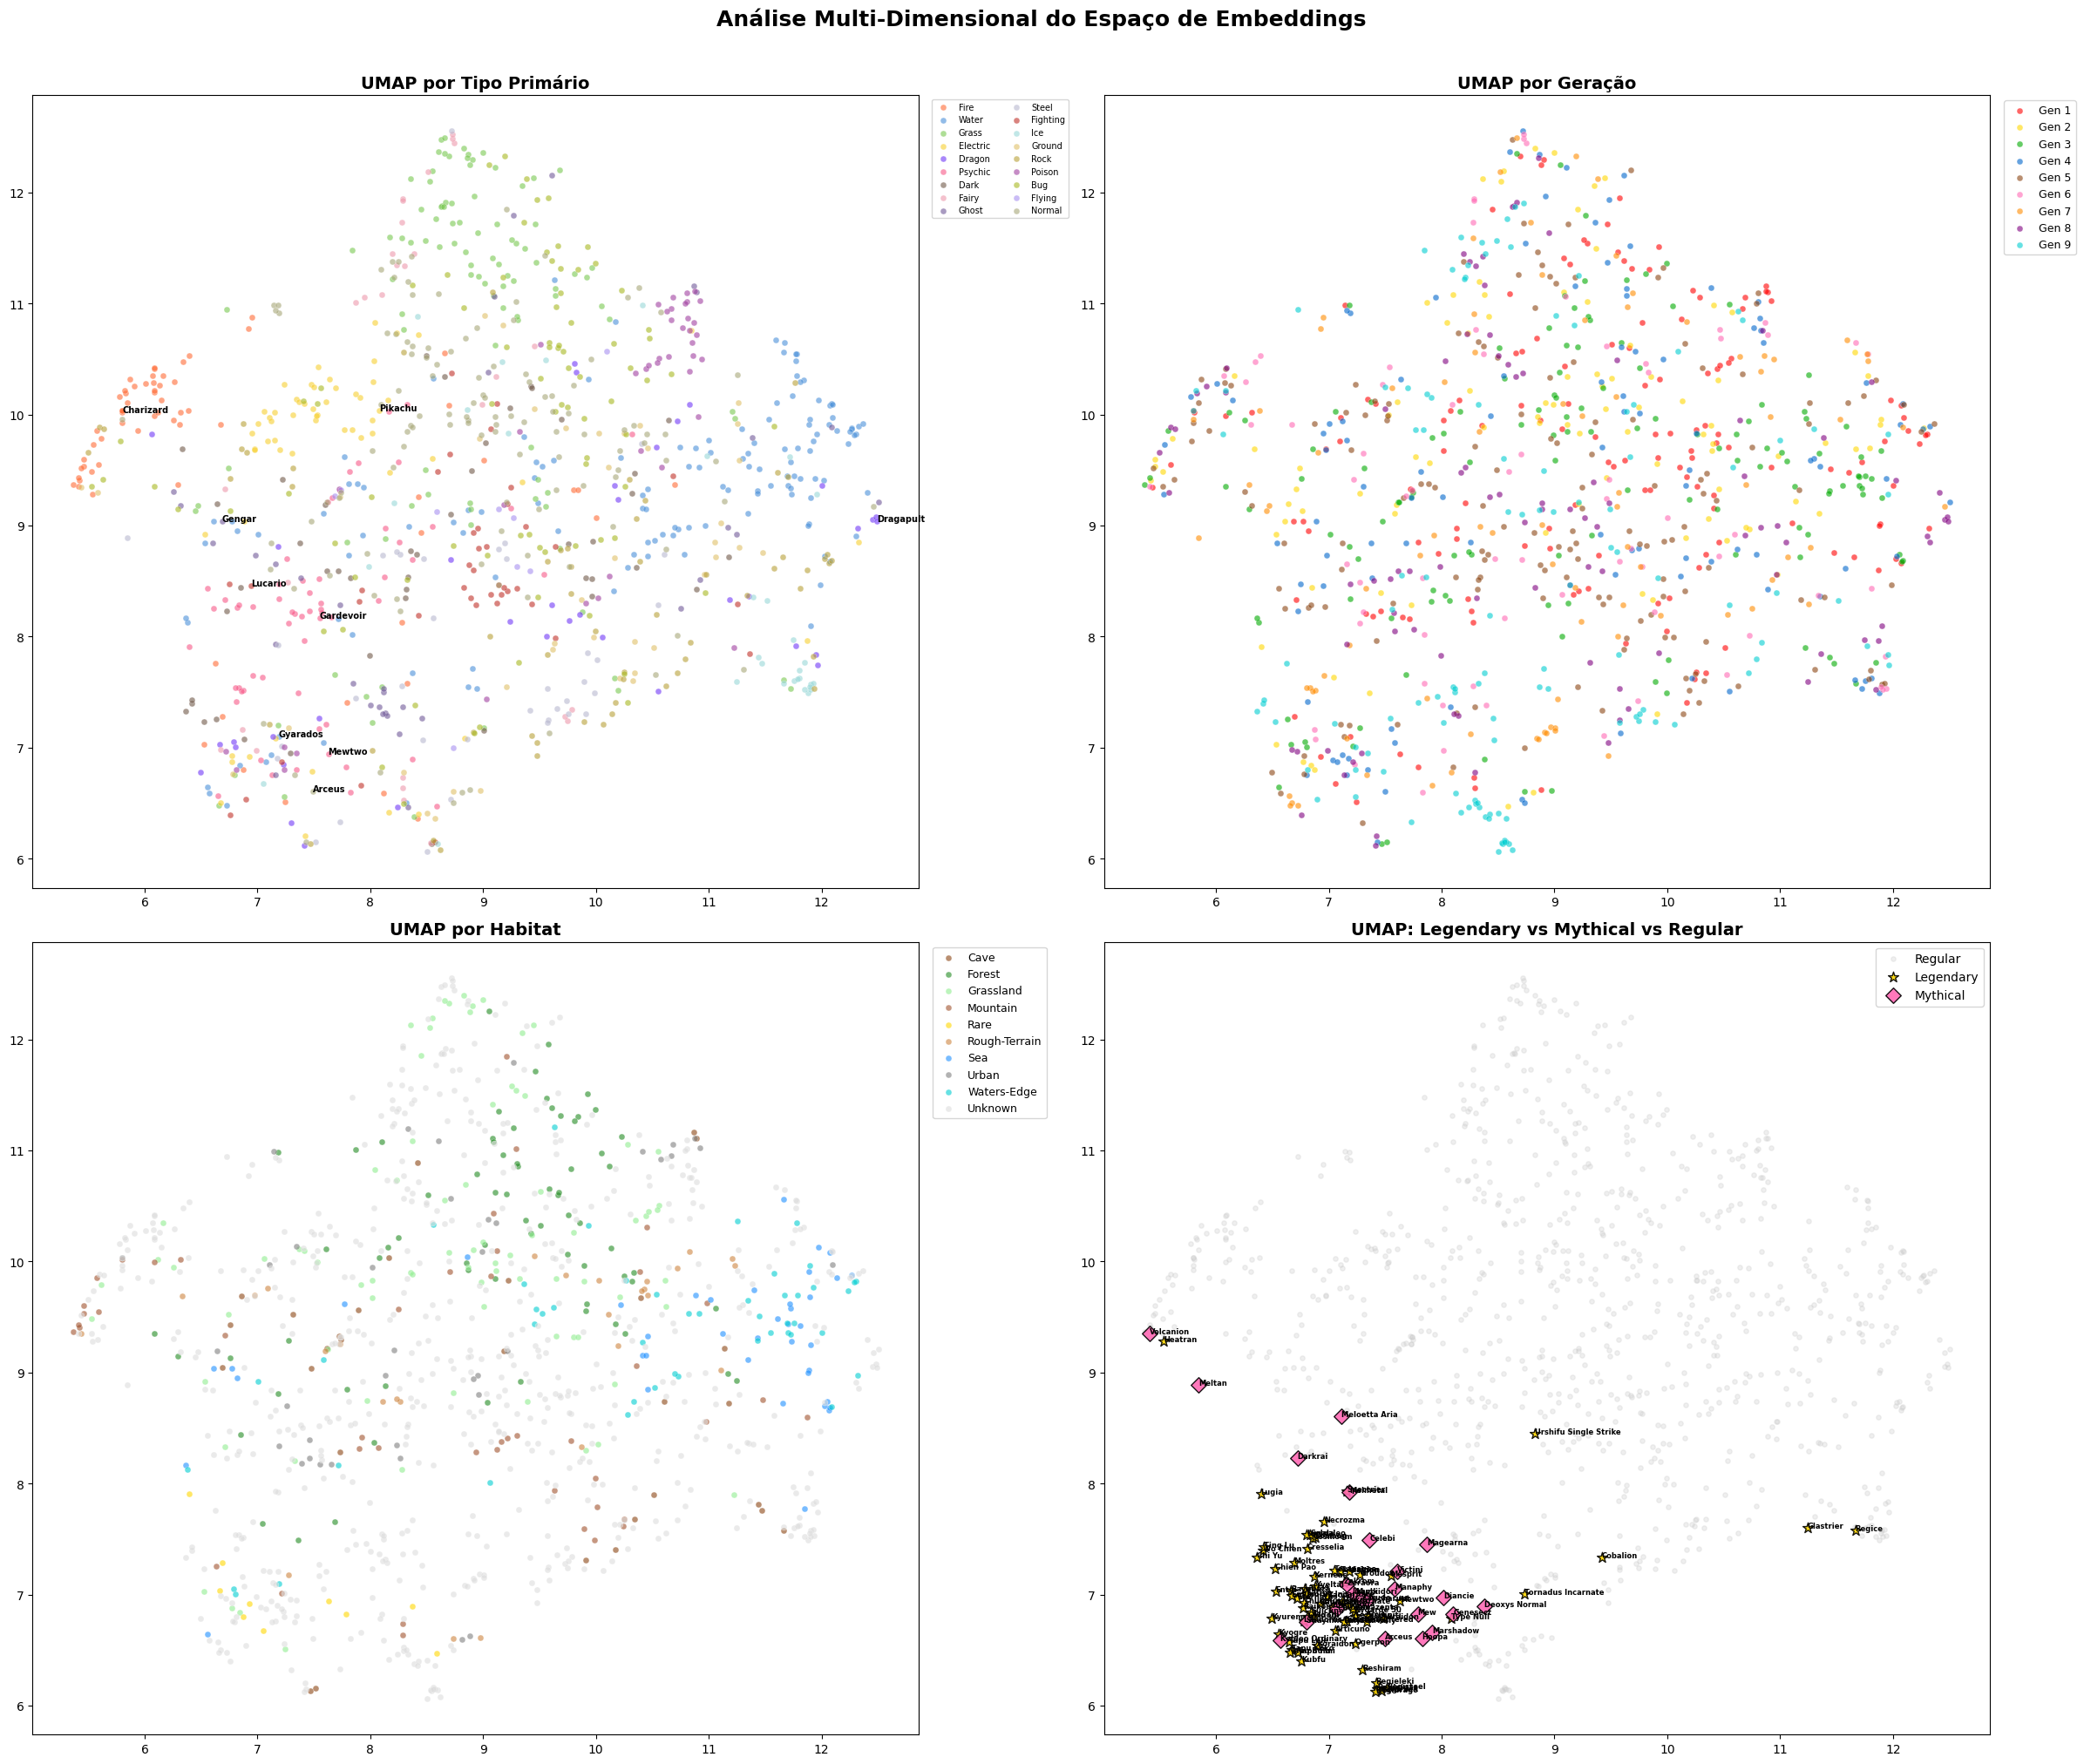

✅ Visualização UMAP salva em pokedex_umap_analysis.png


In [12]:
# ============================================================
# UMAP - melhor preservação de estrutura global que t-SNE
# ============================================================
print("🔄 Calculando UMAP...")

# Usar todos os embeddings
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1, metric='cosine')
umap_coords = reducer.fit_transform(embeddings)

# ── PLOT 1: Por Tipo Primário ──
type_list = ["fire","water","grass","electric","dragon","psychic","dark","fairy","ghost","steel",
             "fighting","ice","ground","rock","poison","bug","flying","normal"]
type_colors = {
    "fire":"#FF6B35","water":"#4A90D9","grass":"#78C850","electric":"#F8D030",
    "dragon":"#7038F8","psychic":"#F85888","dark":"#705848","fairy":"#EE99AC",
    "ghost":"#705898","steel":"#B8B8D0","fighting":"#C03028","ice":"#98D8D8",
    "ground":"#E0C068","rock":"#B8A038","poison":"#A040A0","bug":"#A8B820",
    "flying":"#A890F0","normal":"#A8A878"
}

fig, axes = plt.subplots(2, 2, figsize=(24, 20))

# Plot 1: By primary type
ax = axes[0,0]
for t in type_list:
    mask = df["types"].apply(lambda x: x[0] == t)
    if mask.sum() > 0:
        ax.scatter(umap_coords[mask,0], umap_coords[mask,1], c=type_colors.get(t,'gray'),
                  label=t.title(), alpha=0.6, s=25, edgecolors='white', linewidth=0.3)
# Annotate famous pokemon
for name in ["Charizard","Pikachu","Mewtwo","Gardevoir","Lucario","Gyarados","Dragapult","Arceus","Gengar"]:
    idx = df[df["name"]==name].index
    if len(idx)>0:
        ax.annotate(name,(umap_coords[idx[0],0],umap_coords[idx[0],1]),fontsize=7,fontweight='bold')
ax.set_title("UMAP por Tipo Primário", fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.01,1), loc='upper left', fontsize=7, ncol=2)

# Plot 2: By Generation
ax = axes[0,1]
gen_colors = {1:'#FF0000',2:'#FFD700',3:'#00AA00',4:'#0066CC',5:'#8B4513',6:'#FF69B4',7:'#FF8C00',8:'#800080',9:'#00CED1'}
for gen in range(1,10):
    mask = df["generation"]==gen
    if mask.sum()>0:
        ax.scatter(umap_coords[mask,0],umap_coords[mask,1],c=gen_colors.get(gen,'gray'),
                  label=f"Gen {gen}",alpha=0.6,s=25,edgecolors='white',linewidth=0.3)
ax.set_title("UMAP por Geração", fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.01,1), loc='upper left', fontsize=9)

# Plot 3: By Habitat
ax = axes[1,0]
habitat_colors = {"cave":"#8B4513","forest":"#228B22","grassland":"#90EE90","mountain":"#A0522D",
    "rare":"#FFD700","rough-terrain":"#CD853F","sea":"#1E90FF","urban":"#808080",
    "waters-edge":"#00CED1","unknown":"#DCDCDC"}
for hab, color in habitat_colors.items():
    mask = df["habitat"]==hab
    if mask.sum()>0:
        ax.scatter(umap_coords[mask,0],umap_coords[mask,1],c=color,
                  label=hab.title(),alpha=0.6,s=25,edgecolors='white',linewidth=0.3)
ax.set_title("UMAP por Habitat", fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.01,1), loc='upper left', fontsize=9)

# Plot 4: Legendary/Mythical
ax = axes[1,1]
regular = ~df["is_legendary"] & ~df["is_mythical"]
ax.scatter(umap_coords[regular,0],umap_coords[regular,1],c='#CCCCCC',label='Regular',alpha=0.3,s=15)
legendary = df["is_legendary"]
if legendary.sum()>0:
    ax.scatter(umap_coords[legendary,0],umap_coords[legendary,1],c='#FFD700',label='Legendary',
              alpha=0.9,s=80,edgecolors='black',linewidth=1,marker='*')
    for idx in df[legendary].index:
        ax.annotate(df.loc[idx,"name"],(umap_coords[idx,0],umap_coords[idx,1]),fontsize=6,fontweight='bold')
mythical = df["is_mythical"]
if mythical.sum()>0:
    ax.scatter(umap_coords[mythical,0],umap_coords[mythical,1],c='#FF69B4',label='Mythical',
              alpha=0.9,s=80,edgecolors='black',linewidth=1,marker='D')
    for idx in df[mythical].index:
        ax.annotate(df.loc[idx,"name"],(umap_coords[idx,0],umap_coords[idx,1]),fontsize=6,fontweight='bold')
ax.set_title("UMAP: Legendary vs Mythical vs Regular", fontsize=14, fontweight='bold')
ax.legend(fontsize=10)

plt.suptitle("Análise Multi-Dimensional do Espaço de Embeddings", fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("pokedex_umap_analysis.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualização UMAP salva em pokedex_umap_analysis.png")

## 12. Benchmark de Qualidade Semântica

Medimos a qualidade real dos embeddings com queries manuais e **Recall@K**.
Isso é MAIS importante que qualquer visualização.

📊 Benchmark de Qualidade Semântica (PT-BR)

❌ Query: "pokémon de fogo que voa"
   Recall@20: 0.00% (0/1)
   Hits: nenhum
   Missed: ['chalizard']

❌ Query: "pokemon que parecem deuses divindades criadores do universo"
   Recall@20: 0.00% (0/8)
   Hits: nenhum
   Missed: ['arceus', 'calyrex', 'dialga', 'giratina', 'ho-oh', 'lugia', 'palkia', 'rayquaza']

❌ Query: "pokemon tristes solitários melancólicos abandonados"
   Recall@20: 16.67% (1/6)
   Hits: ['cubone']
   Missed: ['absol', 'banette', 'drifloon', 'mimikyu', 'phantump']

✅ Query: "pokemon do espaço cosmos estrelas lua sol universo"
   Recall@20: 63.64% (7/11)
   Hits: ['cosmoem', 'cosmog', 'lunala', 'lunatone', 'necrozma', 'solgaleo', 'solrock']
   Missed: ['deoxys', 'eternatus', 'jirachi', 'minior']

❌ Query: "pokemon fofos pequenos fada mágicos encantados adoráveis"
   Recall@20: 10.00% (1/10)
   Hits: ['clefairy']
   Missed: ['alcremie', 'comfey', 'dedenne', 'eevee', 'jigglypuff', 'mew', 'mimikyu', 'sylveon', 'togepi']

✅ Que

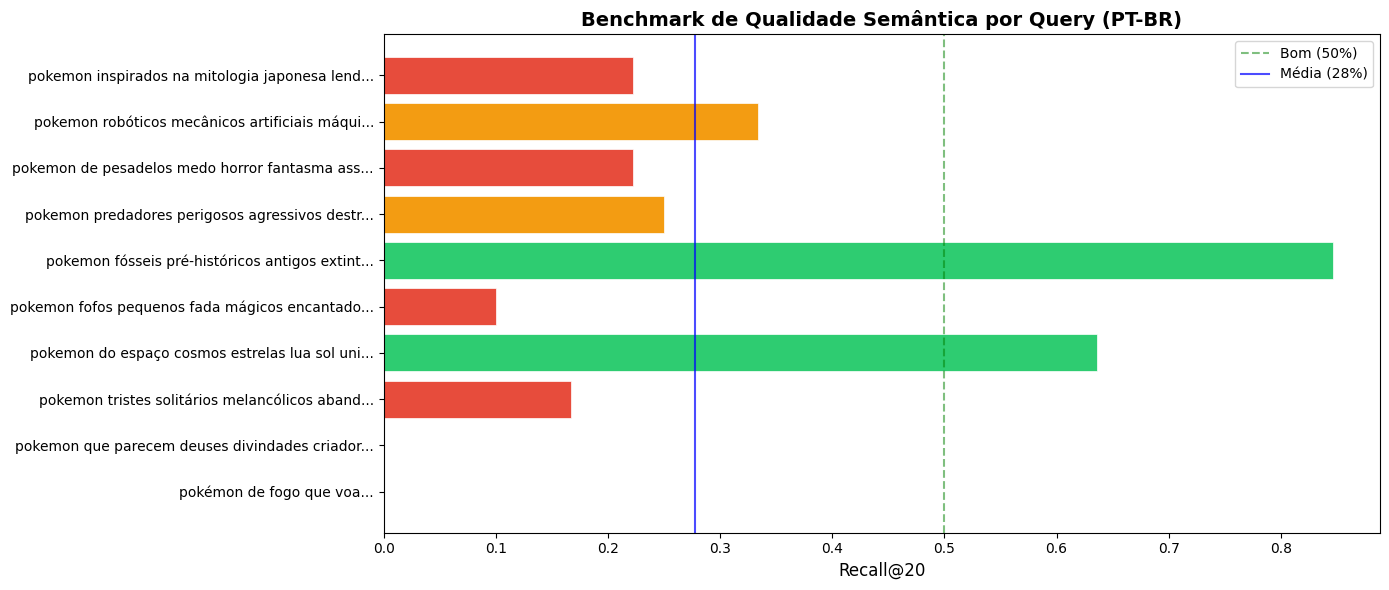

In [ ]:
# Benchmark semântico com ground truth manual - QUERIES EM PT-BR
# (typo "chalizard" corrigido e ground truth expandida para múltiplos Pokémon)
benchmark = {
    "pokémon de fogo que voa": ["charizard", "moltres", "ho-oh", "talonflame", "delphox", "salazzle", "fletchinder"],
    "pokemon que parecem deuses divindades criadores do universo": ["arceus", "dialga", "palkia", "giratina", "ho-oh", "lugia", "rayquaza", "calyrex", "mewtwo", "kyogre", "groudon"],
    "pokemon tristes solitários melancólicos abandonados": ["cubone", "mimikyu", "absol", "banette", "phantump", "drifloon", "yamask", "spiritomb"],
    "pokemon do espaço cosmos estrelas lua sol universo": ["deoxys", "jirachi", "solrock", "lunatone", "cosmog", "cosmoem", "solgaleo", "lunala", "necrozma", "eternatus", "minior", "clefairy"],
    "pokemon fofos pequenos fada mágicos encantados adoráveis": ["clefairy", "jigglypuff", "togepi", "sylveon", "mimikyu", "dedenne", "comfey", "alcremie", "eevee", "mew", "pikachu", "skitty", "azurill"],
    "pokemon fósseis pré-históricos antigos extintos": ["aerodactyl", "omanyte", "kabuto", "anorith", "lileep", "cranidos", "shieldon", "tirtouga", "archen", "tyrunt", "amaura", "dracozolt", "arctovish", "dracovish", "arctozolt"],
    "pokemon predadores perigosos agressivos destrutivos monstros": ["gyarados", "tyranitar", "hydreigon", "garchomp", "salamence", "haxorus", "drapion", "sharpedo", "feraligatr", "krookodile"],
    "pokemon de pesadelos medo horror fantasma assombração terror": ["darkrai", "gengar", "haunter", "duskull", "banette", "spiritomb", "chandelure", "mimikyu", "gourgeist", "trevenant", "dusknoir"],
    "pokemon robóticos mecânicos artificiais máquinas tecnologia": ["magnemite", "magneton", "porygon", "genesect", "magearna", "registeel", "metagross", "golurk", "klinklang", "type-null", "rotom", "beldum"],
    "pokemon inspirados na mitologia japonesa lendas orientais": ["ninetales", "vulpix", "arcanine", "ho-oh", "lugia", "suicune", "absol", "lucario", "zoroark", "greninja", "kommo-o", "honedge", "aegislash", "bisharp", "samurott"],
}


def evaluate_recall(query, expected, top_k=20, use_reranker=True):
    """Calcula Recall@K usando o pipeline híbrido."""
    results = hybrid_search(query, top_k=top_k, use_reranker=use_reranker, show_scores=False)
    retrieved_slugs = set()
    for name in results["Nome"]:
        slug = name.lower().replace(" ", "-")
        retrieved_slugs.add(slug)
    expected_set = set(e.lower() for e in expected)
    hits = retrieved_slugs & expected_set
    recall = len(hits) / len(expected_set) if expected_set else 0
    return recall, hits, retrieved_slugs


print("📊 Benchmark de Qualidade Semântica (PT-BR) — Pipeline Híbrido + Re-ranker")
print("=" * 75)
total_recall = []

for query, expected in benchmark.items():
    recall, hits, retrieved = evaluate_recall(query, expected, top_k=20)
    total_recall.append(recall)
    status = "✅" if recall >= 0.5 else "⚠️" if recall >= 0.25 else "❌"
    print(f"\n{status} Query: \"{query}\"")
    print(f"   Recall@20: {recall:.2%} ({len(hits)}/{len(expected)})")
    print(f"   Hits: {sorted(hits) if hits else 'nenhum'}")
    missed = set(e.lower() for e in expected) - hits
    if missed:
        print(f"   Missed: {sorted(missed)}")

mean_recall = np.mean(total_recall)
print(f"\n{'='*75}")
print(f"📊 Recall@20 Médio: {mean_recall:.2%}")
if mean_recall >= 0.7:
    print(f"   🏆 Excelente!")
elif mean_recall >= 0.5:
    print(f"   👍 Bom")
elif mean_recall >= 0.35:
    print(f"   ⚙️ Aceitável")
else:
    print(f"   ⚠️ Precisa melhorar")

plt.figure(figsize=(14, 6))
queries_short = [q[:50] + ("..." if len(q) > 50 else "") for q in benchmark.keys()]
colors = ['#2ecc71' if r >= 0.5 else '#f39c12' if r >= 0.25 else '#e74c3c' for r in total_recall]
plt.barh(queries_short, total_recall, color=colors, edgecolor='white', linewidth=0.5)
plt.xlabel("Recall@20", fontsize=12)
plt.title("Benchmark de Qualidade Semântica — Pipeline Híbrido (PT-BR)", fontsize=14, fontweight='bold')
plt.axvline(x=0.5, color='green', linestyle='--', alpha=0.5, label='Bom (50%)')
plt.axvline(x=mean_recall, color='blue', linestyle='-', alpha=0.7, label=f'Média ({mean_recall:.0%})')
plt.legend()
plt.tight_layout()
plt.savefig("semantic_benchmark.png", dpi=150, bbox_inches='tight')
plt.show()


## 12. Exportação do Índice e Dados

In [ ]:
# Salvar tudo (denso + esparso + metadados)
OUTPUT_DIR = Path("pokedex_semantic_search")
OUTPUT_DIR.mkdir(exist_ok=True)

# 1. FAISS index (denso)
faiss.write_index(index, str(OUTPUT_DIR / "pokedex.index"))

# 2. Embeddings numpy
np.save(str(OUTPUT_DIR / "embeddings.npy"), embeddings)

# 3. DataFrame com metadados
df.to_pickle(str(OUTPUT_DIR / "pokedex_metadata.pkl"))
df.to_csv(str(OUTPUT_DIR / "pokedex_metadata.csv"), index=False)

# 4. Documentos textuais
with open(OUTPUT_DIR / "documents.json", "w", encoding="utf-8") as f:
    json.dump(documents, f, ensure_ascii=False, indent=2)

# 5. BM25 (índice esparso) + tokens
with open(OUTPUT_DIR / "bm25.pkl", "wb") as f:
    pickle.dump({"bm25": bm25, "tokenized_docs": tokenized_docs}, f)

# 6. Config (nomes dos modelos para reprodutibilidade)
config = {
    "embed_model": EMBED_MODEL_NAME,
    "reranker_model": RERANKER_NAME if USE_RERANKER else None,
    "dimension": int(dimension),
    "total_pokemon": int(len(df)),
    "embedding_strategy": "passage:/query: prefix (E5 style)",
}
with open(OUTPUT_DIR / "config.json", "w", encoding="utf-8") as f:
    json.dump(config, f, ensure_ascii=False, indent=2)

print("✅ Arquivos exportados:")
for f in OUTPUT_DIR.iterdir():
    size = f.stat().st_size / 1024
    print(f"   📁 {f.name} ({size:.1f} KB)")

# Compactar para download
!cd pokedex_semantic_search && zip -r ../pokedex_semantic_search.zip .
print("\n📦 Arquivo compactado: pokedex_semantic_search.zip")
print("   Use Files > Download para baixar no Colab")


✅ Arquivos exportados:
   📁 documents.json (1852.6 KB)
   📁 pokedex.index (1537.5 KB)
   📁 pokedex_metadata.pkl (1996.7 KB)
   📁 pokedex_metadata.csv (1987.6 KB)
   📁 embeddings.npy (1537.6 KB)
  adding: documents.json (deflated 75%)
  adding: pokedex.index (deflated 7%)
  adding: pokedex_metadata.pkl (deflated 76%)
  adding: pokedex_metadata.csv (deflated 76%)
  adding: embeddings.npy (deflated 7%)

📦 Arquivo compactado: pokedex_semantic_search.zip
   Use Files > Download para baixar no Colab
